<a href="https://colab.research.google.com/github/graciemwilliams/EDA/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis
### `! git clone https://github.com/ds4e/EDA`
### Do Q1 and two other questions.

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Instead of the mean, consider the median. Consider transformations that are non-decreasing (if $x\ge x'$, then $g(x)\ge g(x')$), like $2+5 \times X$ or $\text{arcsinh}(X)$. Is a non-decreasing transformation of the median the median of the transformed variable? Explain. Does your answer apply to any quantile? The IQR? The range?
5. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

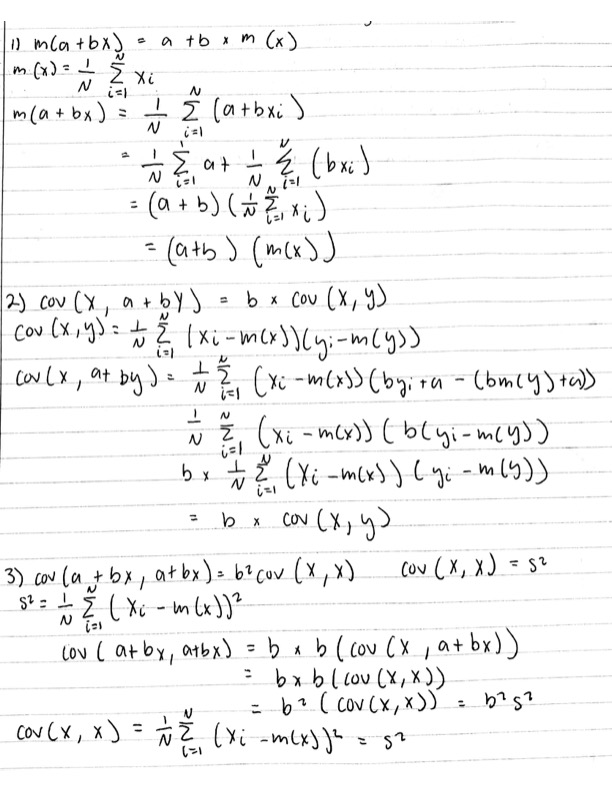

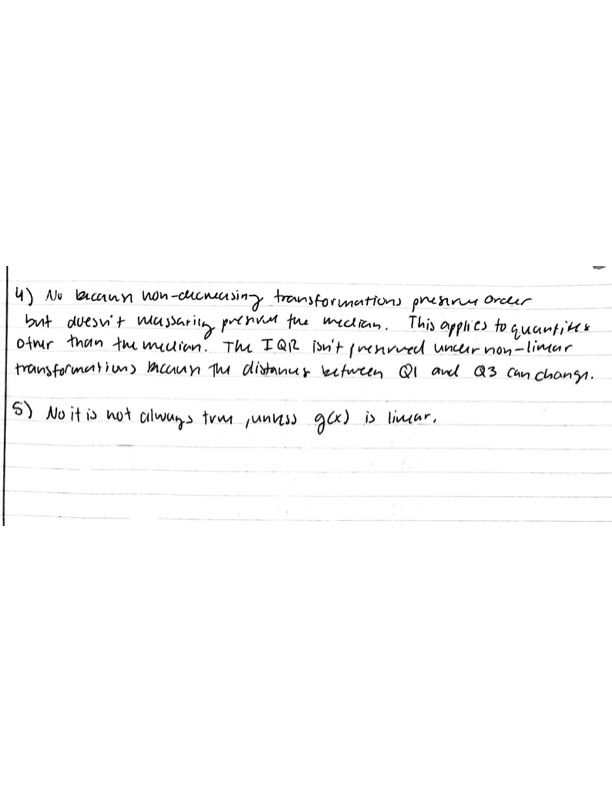

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

## Part 1

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# import the csv document
from google.colab import files
uploaded = files.upload()

Saving ForeignGifts_edu.csv to ForeignGifts_edu.csv


In [8]:
# read in the data
df = pd.read_csv('ForeignGifts_edu.csv')
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


## Part 2

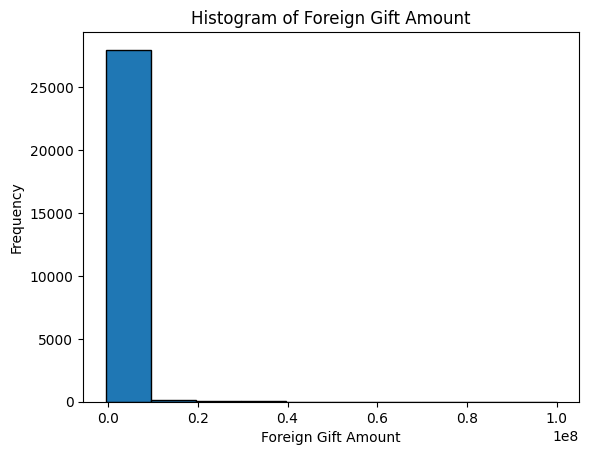

In [27]:
# make a histogram of the foreign gift amount
plt.hist(df['Foreign Gift Amount'], bins=10, edgecolor='black')
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Frequency")
plt.title("Histogram of Foreign Gift Amount")
plt.show()

In [28]:
df['Foreign Gift Amount'].describe()

,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


There is a lot of variation in the foreign gift amount variable. The x axis has values from 0 to 100 million with the mean being around 600,000. 75% of the gifts are less than 400,000. The max value of 100 million seems to be skewing the graph and affecting the mean value.

## Part 3

In [34]:
# create a value counts table of gift type
df['Gift Type'].value_counts()

# find the proportions of the the different types
df['Gift Type'].value_counts(normalize=True)

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


## Part 4

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


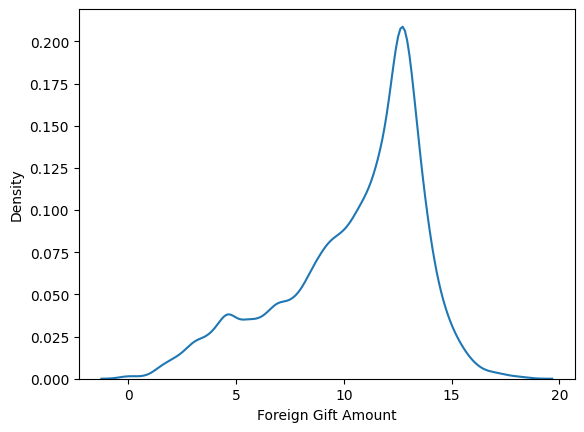

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


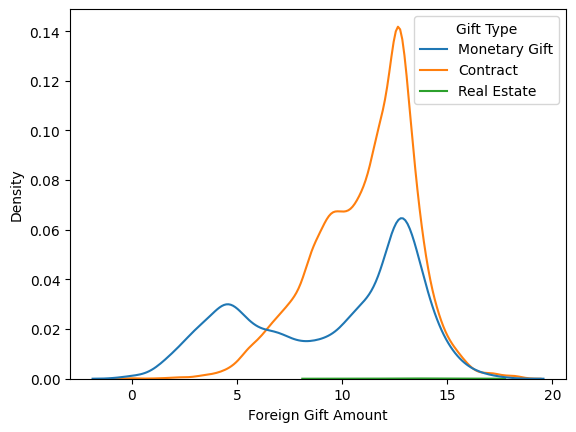

In [40]:
# create a kde of the log of foreign gift amount
sns.kdeplot(np.log(df['Foreign Gift Amount']))
plt.show()

# create a kde of the log of foreign gift amount conditional on gift type
sns.kdeplot(data=df, x=np.log(df['Foreign Gift Amount']), hue=df['Gift Type'])
plt.show()

One thing that I notice is that the contract gift type appears to be most similar to kde plot of the first graph.

## Part 5


In [43]:
# find the top 15 countries in terms of the number of gifts
print(df['Country of Giftor'].value_counts().head(15))

# find the top 15 countries in terms of the amount of money given
print(df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15))

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


## Part 6

In [44]:
# top 15 institutions in terms of the total amount of money they receive
print(df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15))

Institution Name
Carnegie Mellon University                       1477922504
Cornell University                               1289937761
Harvard University                                954803610
Massachusetts Institute of Technology             859071692
Yale University                                   613441311
Texas A&M University                              521455050
Johns Hopkins University                          502409595
Northwestern University                           402316221
Georgetown University                             379950511
University of Chicago (The)                       364544338
University of Colorado Boulder                    360173159
Duke University                                   343699498
Brigham Young University                          323509863
Stanford University                               319561362
University of Texas MD Anderson Cancer Center     301527419
Name: Foreign Gift Amount, dtype: int64


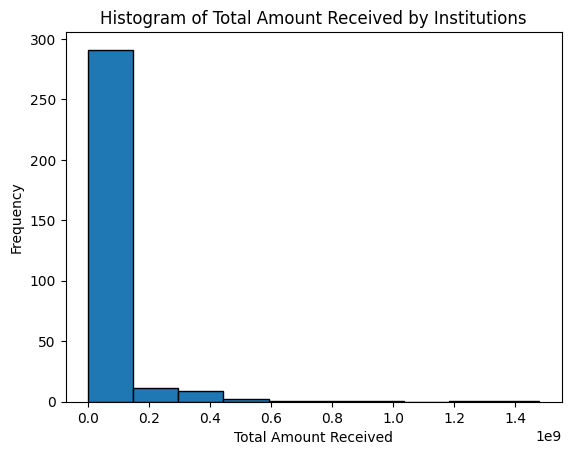

In [50]:
# make a histogram of the total amount of money received by all institutions
plt.hist(df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False), bins=10, edgecolor='black')
plt.xlabel("Total Amount Received")
plt.ylabel("Frequency")
plt.title("Histogram of Total Amount Received by Institutions")
plt.show()

## Part 7

In [47]:
# find which giftors provided the most money in total
print(df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15))

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


The Quatar Foundation provided the most money, in total.

**Q4.** This question looks at a time series of the number of active oil drilling rigs in the United States over time. The data comes from the Energy Information Agency.


In [64]:
# import the csv document
from google.colab import files
uploaded = files.upload()

Saving drilling_rigs.csv to drilling_rigs (1).csv


In [72]:
df.head()

,Month,"Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)","Crude Oil and Natural Gas Rotary Rigs in Operation, Offshore (Number of Rigs)","Crude Oil Rotary Rigs in Operation, Total (Number of Rigs)","Natural Gas Rotary Rigs in Operation, Total (Number of Rigs)","Crude Oil and Natural Gas Rotary Rigs in Operation, Horizontal Trajectory (Number of Rigs)","Crude Oil and Natural Gas Rotary Rigs in Operation, Directional Trajectory (Number of Rigs)","Crude Oil and Natural Gas Rotary Rigs in Operation, Vertical Trajectory (Number of Rigs)","Crude Oil and Natural Gas Rotary Rigs in Operation, Total (Number of Rigs)",Active Well Service Rig Count (Number of Rigs),time
0,1973 January,1120,99,Not Available,Not Available,Not Available,Not Available,Not Available,1219,NaN,1973-01-01
1,1973 February,1037,89,Not Available,Not Available,Not Available,Not Available,Not Available,1126,NaN,1973-02-01
2,1973 March,959,90,Not Available,Not Available,Not Available,Not Available,Not Available,1049,0.0,1973-03-01
3,1973 April,914,79,Not Available,Not Available,Not Available,Not Available,Not Available,993,-35.0,1973-04-01
4,1973 May,974,72,Not Available,Not Available,Not Available,Not Available,Not Available,1046,0.0,1973-05-01


## Part 1

In [65]:
df = pd.read_csv('drilling_rigs.csv')

# find the number of observations
print(df.shape[0])

# find the number of variables
print(df.shape[1])

# find the data types of each variable
print(df.dtypes)

623
10
Month                                                                                          object
Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)                    int64
Crude Oil and Natural Gas Rotary Rigs in Operation, Offshore (Number of Rigs)                   int64
Crude Oil Rotary Rigs in Operation, Total (Number of Rigs)                                     object
Natural Gas Rotary Rigs in Operation, Total (Number of Rigs)                                   object
Crude Oil and Natural Gas Rotary Rigs in Operation, Horizontal Trajectory (Number of Rigs)     object
Crude Oil and Natural Gas Rotary Rigs in Operation, Directional Trajectory (Number of Rigs)    object
Crude Oil and Natural Gas Rotary Rigs in Operation, Vertical Trajectory (Number of Rigs)       object
Crude Oil and Natural Gas Rotary Rigs in Operation, Total (Number of Rigs)                      int64
Active Well Service Rig Count (Number of Rigs)                             

Several columns that should be stored as integers are stored as objects, such as Natural Gas Rotary Rigs in Operation and other variables that count the number of rigs. There is a lot of NaN variables in those columns so that is likely why they are being typecast as objects. These columns need to be converted into integers after missing values are removed.

## Part 2



In [66]:
# convert the month variable to an ordered datetime variable
df['time'] = pd.to_datetime(df['Month'], format='mixed')

## Part 3

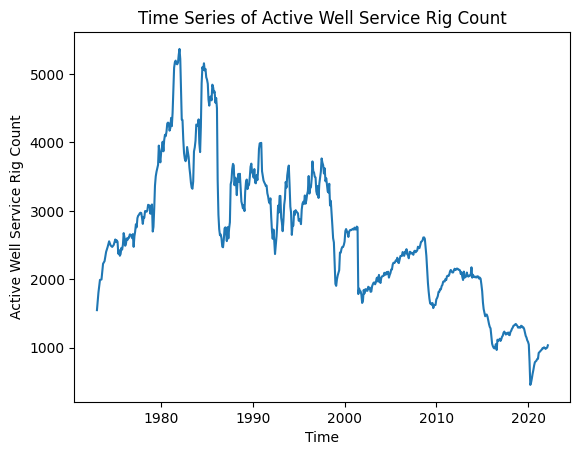

In [68]:
# change the columns ex
df['Active Well Service Rig Count (Number of Rigs)'] = pd.to_numeric(df['Active Well Service Rig Count (Number of Rigs)'], errors="coerce")
# clean the variable by removing Na values
df = df.dropna(subset=['Active Well Service Rig Count (Number of Rigs)'])


# make a line plot of the active well service rig count
plt.plot(df['time'], df['Active Well Service Rig Count (Number of Rigs)'])
plt.xlabel("Time")
plt.ylabel("Active Well Service Rig Count")
plt.title("Time Series of Active Well Service Rig Count")
plt.show()

I see a peak in the 1980s and then it appears to decline up until 2020. There were quite a few missing values however, so I wonder if there is still a similar amount of active well service rigs, but the values are just missing.

## Part 4

<ipython-input-70-02218478b956>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Active Well Service Rig Count (Number of Rigs)'] = df['Active Well Service Rig Count (Number of Rigs)'].diff()


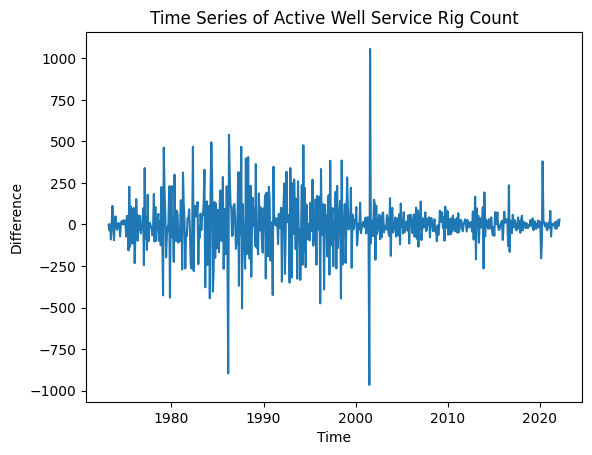

In [70]:
# compute the first difference of active well service rig count and plot it over time
df['Active Well Service Rig Count (Number of Rigs)'] = df['Active Well Service Rig Count (Number of Rigs)'].diff()
plt.plot(df['time'], df['Active Well Service Rig Count (Number of Rigs)'])
plt.xlabel("Time")
plt.ylabel("Difference")
plt.title("Time Series of Active Well Service Rig Count")
plt.show()

This graph shows that there was a significant increase in rigs around 1985 and a significant increase and then decrease in the early 2000s. Overall the differences have gotten smaller since the 2000s, however it looks like in 2016-2020 there were increases in the rig counts. This could be relfective of energy politicies in the first Trump presidency.

## Part 5

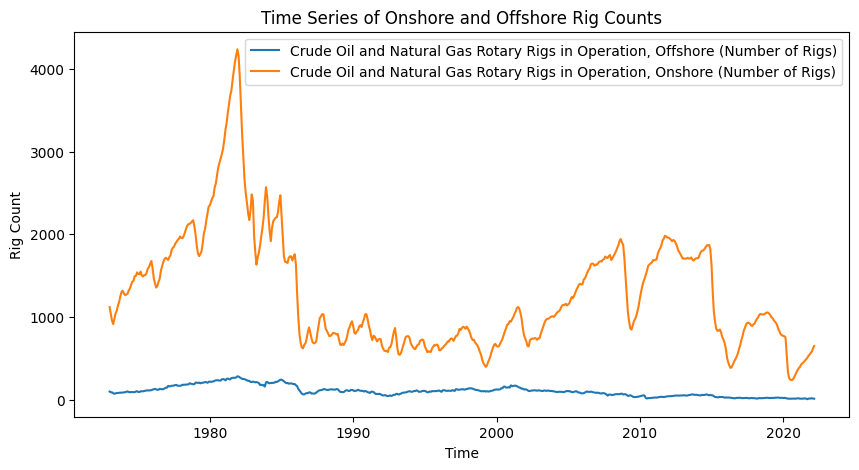

In [74]:
# melt the columns for onshore and offshore rigs
df_melted = pd.melt(df, id_vars=['time'], value_vars=['Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)', 'Crude Oil and Natural Gas Rotary Rigs in Operation, Offshore (Number of Rigs)'], var_name='Rig Type', value_name='Rig Count')

# plot the resulting series
plt.figure(figsize=(10, 5))

for rig_type, data in df_melted.groupby('Rig Type'):
    plt.plot(data['time'], data['Rig Count'], label=rig_type)

plt.xlabel("Time")
plt.ylabel("Rig Count")
plt.title("Time Series of Onshore and Offshore Rig Counts")
plt.legend()
plt.show()